# Implement Baillard-Like 2D Histogram to Visualize Splitting Parameters vs. Time

In [18]:
# Dependencies

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import obspy
from obspy.core.utcdatetime import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.core.event import read_events
import os
import sys
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add local swspy directory to path (before other imports)
swspy_local_path = os.path.abspath('../swspy')
if swspy_local_path not in sys.path:
    sys.path.insert(0, swspy_local_path)

# Import swspy from local directory
import swspy

# Add scripts directory to path for custom modules
sys.path.append('.')
from get_all_traces import get_station_traces_batch
from splitting_functions import *
from teanby_clustering import *

# Set up plotting
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully")
print(f"ObsPy version: {obspy.__version__}")
print(f"SWSPy available: {'Yes' if 'swspy' in sys.modules else 'No'}")
print(f"SWSPy location: {swspy.__file__}")

import sws_methods as swm
# Import helper functions needed for plot_movehisto2d
from sws_methods import movehisto2d_bin, timestamp2matplotlib, XY2XY_pcolormesh

Libraries imported successfully
ObsPy version: 1.4.2
SWSPy available: Yes
SWSPy location: /Users/mhemmett/Seismology/axial-splitting-ml/swspy/swspy/__init__.py


In [19]:
# Import processed results
results_swspy_axas2 = pd.read_csv('../results/splitting_results_swspy_axas2_april_20_28_2_sigma_start.csv')

In [20]:
display(results_swspy_axas2.head())

,event_id,event_datetime,event_lat,event_lon,event_depth,back_azimuth,incidence,snr_horizontal,rectilinearity,phi,phi_error,dt,dt_error,first_window_start,last_window_start,first_window_end,last_window_end,n_windows
0,41214,2015-04-20T00:01:42.086476Z,45.936755,-130.019761,1.43125,307.809704,11.757650,3.359480,0.940040,87.809704,55.0,0.07,0.035,2 Terr,0 Terr,1.5 Tmid,2.5 Tmid,10
1,41215,2015-04-20T00:01:57.105395Z,45.940423,-129.998249,0.19375,59.693376,8.270292,11.359208,0.953208,85.693376,32.0,0.11,0.025,2 Terr,0 Terr,1.5 Tmid,2.5 Tmid,10
2,41218,2015-04-20T00:04:13.748602Z,45.936473,-130.020573,1.49375,301.630577,7.804983,2.458731,0.965286,-0.369423,22.0,0.02,0.005,2 Terr,0 Terr,1.5 Tmid,2.5 Tmid,10
3,41219,2015-04-20T00:04:19.796830Z,45.938166,-130.018338,1.21875,326.803457,10.016922,3.113523,0.956437,-87.196543,63.0,0.07,0.030,2 Terr,0 Terr,1.5 Tmid,2.5 Tmid,10
4,41223,2015-04-20T00:05:16.747554Z,45.941129,-130.015291,0.74375,354.286672,5.125676,3.587528,0.831094,-89.713328,26.0,0.01,0.035,2 Terr,0 Terr,1.5 Tmid,2.5 Tmid,10


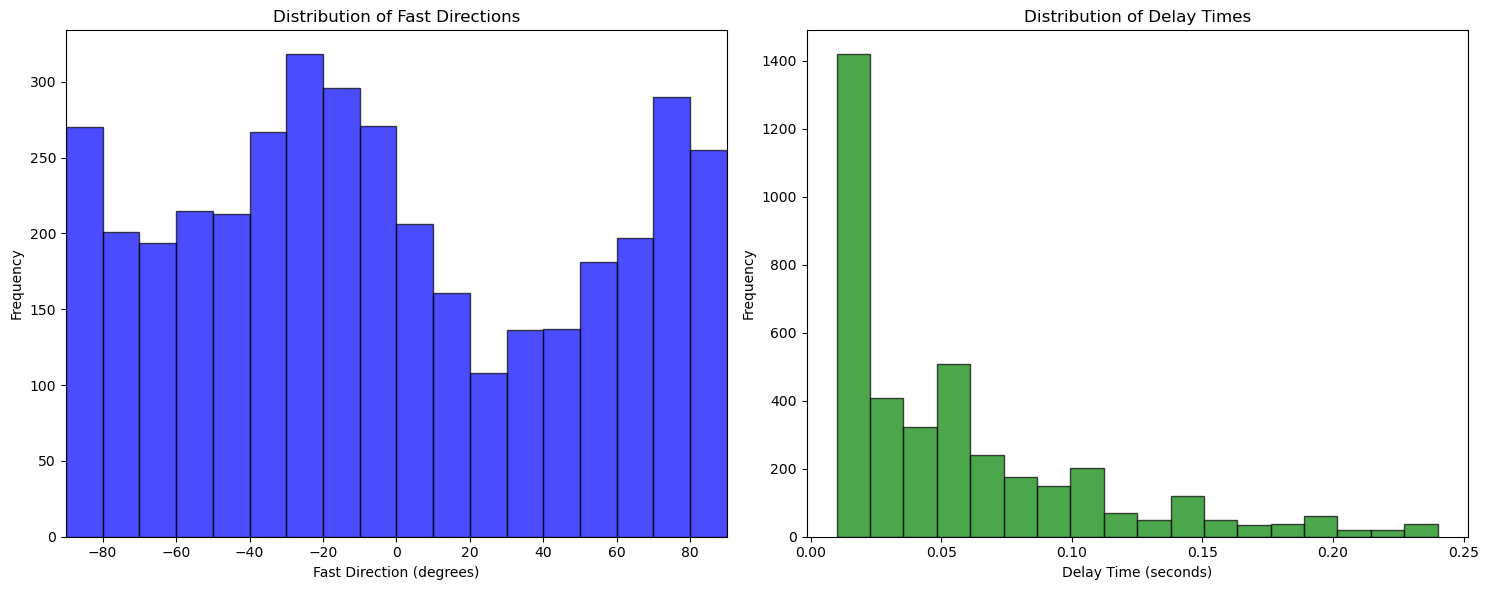

In [30]:
# Plot a histogram of fast directions and a histogram of delay times
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].hist(results_swspy_axas2['phi'], bins=18,
              alpha=0.7, color='blue', edgecolor='black')
axes[0].set_xlabel('Fast Direction (degrees)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(-90, 90)
axes[0].set_title('Distribution of Fast Directions')

axes[1].hist(results_swspy_axas2['dt'], bins=18,
              alpha=0.7, color='green', edgecolor='black')
axes[1].set_xlabel('Delay Time (seconds)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Delay Times')

plt.tight_layout()
plt.show()

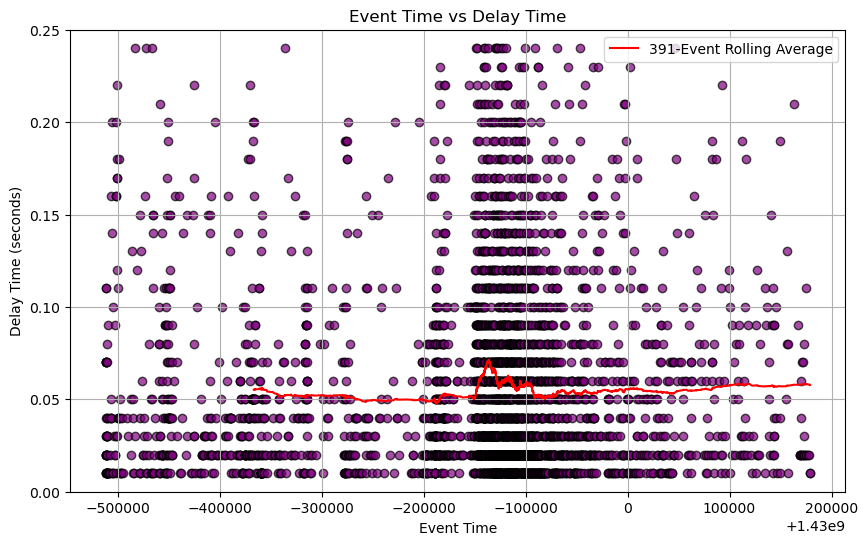

In [43]:
# Plot the scatter of time vs delay time

plt.figure(figsize=(10, 6))
plt.scatter(times, dts, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel('Event Time')
plt.ylabel('Delay Time (seconds)')
plt.title('Event Time vs Delay Time')
plt.ylim(0, 0.25)
plt.grid(True)

# Plot rolling average of delay times
window_size = 391 # Adjust the window size as needed
rolling_avg = pd.Series(dts).rolling(window=window_size).mean()
plt.plot(times, rolling_avg, color='red', label=f'{window_size}-Event Rolling Average')
plt.legend()
plt.show()

In [47]:
# Import processed results
results_swspy_axas2_validation = pd.read_csv('../results/splitting_results_axas2_apr_20_28_sigma_2_validation.csv')

In [48]:
# Pull relevant categories for plotting
# pull out event_datetime as array of UTCDateTime objects (they are in that type already)
times_val = np.array([UTCDateTime(t) for t in results_swspy_axas2_validation['event_datetime']])
dts_val = np.array(results_swspy_axas2_validation['dt'])
phis_val = np.array(results_swspy_axas2_validation['phi'])

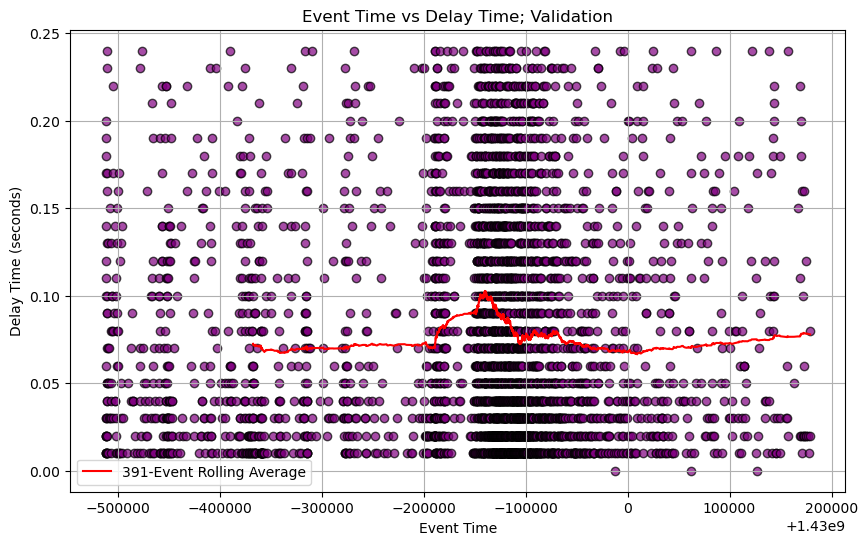

In [50]:
# Plot the scatter of time vs delay time

plt.figure(figsize=(10, 6))
plt.scatter(times_val, dts_val, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel('Event Time')
plt.ylabel('Delay Time (seconds)')
plt.title('Event Time vs Delay Time; Validation')
plt.grid(True)

# Plot rolling average of delay times
window_size = 391 # Adjust the window size as needed
rolling_avg = pd.Series(dts_val).rolling(window=window_size).mean()
plt.plot(times_val, rolling_avg, color='red', label=f'{window_size}-Event Rolling Average')
plt.legend()
plt.show()

In [38]:
# Pull relevant categories for plotting
# pull out event_datetime as array of UTCDateTime objects (they are in that type already)
times = np.array([UTCDateTime(t) for t in results_swspy_axas2['event_datetime']])
dts = np.array(results_swspy_axas2['dt'])
phis = np.array(results_swspy_axas2['phi'])

In [70]:
def plot_movehisto2d(x,y,
                x_label='X',y_label='Y',title='',ax=None,vmax=None,
                **movehisto2d_kwargs):


    """
    Function made to plot an histo2d but using a moving window in both directionsn, this ensure better
    consistency between neighbor bins. 
    The histogram can also work when data is an obspy.UTCDateTime array, then the x_start and x_end must
    be given in UTCDateTime as well and the x_width should be given in seconds.
    UTCDatetime are converted to timestamps (seconds since 1970)
    
    Inputs
    ------
        x,y: np.array: arrays containing the data to apply histogram on (x can be UTCDateTime)
        x_width,y_width: float: width of the bins (in seconds for UTCDateTime)
        [x,y]_[start,end]: float: start and end for histogram edges
        [x,y]_over: float in [0,1]: overlap for windows [1 = full overlap]
        norm_y: Boolean: True to normalize by the maximum in each column
        smooth: Boolean: True for smoothin (Gaussian Filter)
        gaussian_[x,y]_per: float in [0,100]: width percentage for smoothing (100= filter size equal to data range)
        [x,y]_label: str
        text_list: list,str: titles to be added to the right corner of the figure
        show_counts: bool: If True it will add subplots to shown counts
        
    Ouputs
    ------
        ax_list: plt.axes: object associated to the 4 plots (top,text,mesh,right)
        X,Y,Z: meshes :
        x_bins,x_diffs : x_diffs is in seconds, whereas x_bins in matplotlib time
            x_diffs is the time resolution (i.e. the size of the bins, should be constant
            if windows is used)
    
    Comments:
    ---------
        To be added to the general functions (plot module?)
        x_start and x_end needs to be modified for samples plots
        
    UsedIn
    ------
        SWSCat.plot_movehisto2d_time
    """
    
    ### Check if is made of UTCDateTimes
    
    time_flag=False
    if isinstance(x[0],UTCDateTime):
        time_flag=True
        print('X is in UTCDateTime')
        if movehisto2d_kwargs.get('x_mode','window')=='window':
            print('Remember width should be given in seconds, otherwise memory error')
    
    ### Modify x_start and x_end, and x if x is time and convert to timestamps
    x_start=movehisto2d_kwargs.get('x_start',None)
    x_end=movehisto2d_kwargs.get('x_end',None)
    y_start=movehisto2d_kwargs.get('y_start',None)
    y_end=movehisto2d_kwargs.get('y_end',None)
    
    if time_flag:
        if (x_start is not None) & (not isinstance(x_start,UTCDateTime)):
            raise ValueError('x_start must be given in obspy.UTCDateTime')
        if (x_end is not None) & (not isinstance(x_end,UTCDateTime)):
            raise ValueError('x_end must be given in obspy.UTCDateTime')
        x=np.array([value.timestamp for value in x]) # (seconds since 1970-01-01T00:00:00)
        x_start=x_start.timestamp if x_start is not None else None
        x_end=x_end.timestamp if x_end is not None else None
        movehisto2d_kwargs['x_start']=x_start
        movehisto2d_kwargs['x_end']=x_end

    ### Bin the data
    
    (X,Y,Z,x_bins,x_diffs)=movehisto2d_bin(x,y,**movehisto2d_kwargs)
    
    ### Normalize to density (sum to 1)
    Z_total = np.sum(Z)
    if Z_total > 0:
        Z = Z / Z_total
    
    ########################
    #### Start plotting ####

    #### Grid spec
    
        fig,ax = plt.subplots(figsize=(12, 4), gridspec_kw={'bottom':0.15,'left':0.15})
    
    ### Checks
    
    if ax is None:
        fig,ax = plt.subplots(gridspec_kw={'bottom':0.15,'left':0.15})
        
    if time_flag:
        X=np.array(timestamp2matplotlib(X.ravel())).reshape(X.shape) # transform for plotting
        x_bins=timestamp2matplotlib(x_bins)
        plt.setp( ax.xaxis.get_majorticklabels(), rotation=30 ,ha='right')
        ax.set_xlim(timestamp2matplotlib([x_start,x_end]))
    else:
        ax.set_xlim([x_start,x_end])
       
    (Xm,Ym)=XY2XY_pcolormesh(X,Y) # To ensure Pcolormesh will be ceneterd on bins

    #im=ax.pcolormesh(X,Y,Z,cmap=plt.cm.get_cmap('jet'),rasterized=True)
    im=ax.pcolormesh(Xm,Ym,Z,cmap=plt.cm.get_cmap('magma'),rasterized=True,vmax=vmax)
    
    ax.set_ylim([y_start,y_end])
    
    ax.set_aspect('auto')
    if time_flag:
        ax.xaxis_date()
            
    ### Cosmetic
    
    ax.set_ylabel(y_label) 
    if not time_flag:

        ax.set_xlabel(x_label)     
        
    return (ax,im,X,Y,Z,x_bins,x_diffs)

       
    ###### Return

In [59]:
# Debug the data
print(f"Number of data points: {len(times)}")
print(f"Time range: {times.min()} to {times.max()}")
print(f"DT range: {dts.min():.3f} to {dts.max():.3f} seconds")
print(f"DT mean: {dts.mean():.3f}, median: {np.median(dts):.3f}")
print(f"Time span in days: {(times.max() - times.min()) / 86400:.1f}")

Number of data points: 3916
Time range: 2015-04-20T00:01:42.086476Z to 2015-04-27T23:55:47.855544Z
DT range: 0.010 to 0.240 seconds
DT mean: 0.057, median: 0.040
Time span in days: 8.0


X is in UTCDateTime
Remember width should be given in seconds, otherwise memory error


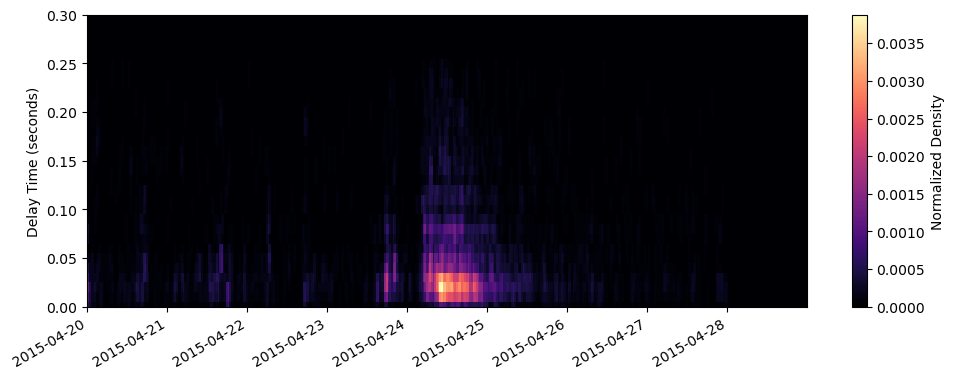

In [71]:
# Plot the data with corrected parameters
# y_end should match your actual data range (0.01-0.24 seconds, not 250!)
# x_width in seconds (e.g., 86400 = 1 day, 43200 = 12 hours)
# y_width should be appropriate for your data scale (e.g., 0.01-0.02 seconds)
plot_movehisto2d(x=times,y=dts,x_label='Time',y_label='Delay Time (seconds)',title='Delay Time vs Time',
                 x_start=UTCDateTime("2015-04-20T00:00:00"),x_end=UTCDateTime("2015-04-28T23:59:59"),
                 y_start=0,y_end=0.30,x_width=43200 / 12,x_over=0.5,y_width=0.02,y_over=0.5,vmax=None)  
plt.colorbar(plt.gca().collections[0], label='Normalized Density')
plt.show()

In [64]:
from sws_methods import obspytime2matplotlib

In [65]:
def plot_movehisto2d_time(times, dts, y_param, 
                              x_label='X',y_label='Y',title='',ax=None,
                              
                              angle_mode='trigo',lag_mode='sample',sampling_rate=200,
                              window_unit=None,window_bottom=None,window_top=None,
                              **movehisto2d_kwargs):
        """
        Function made to use movehist_2d and show variations of splitting parameters with time
        parameters are similat to the one for movehisto2d
        Plots showing angles used trigo convention by default (ie CCW from East) however angles can
        be shown using azimuth conention by specifyin angle_mode='azimuth', in that case all paramters
        should be given using that convention (ie. y_width, y_start,y_cycle...)
        
        parameter should be given in degrees
        
        Input
        ----
            angle_mode: str: ['trigo','azimuth']
            lag_mode: str: ['sample','ms','s']
            sampling_rate: float: sampling rate of the data to convert lags from samples to ms
        """

        
        ### Retrieve proper parameters
        
        
        ### Select arrays 
        
        x=times
        y=dts * 200
        
        ### Convert raduians to degress
        if y_param=='fast':
            y=y*180/np.pi
            
        ### Change angle mode and lag_model if asked
        
        if y_param=='fast':
            if angle_mode=='azimuth':
                y=swm.trigo2azimuth(y)
        elif y_param=='lag':
            if lag_mode=='ms':
                y=y/sampling_rate*1000
            elif lag_mode=='s':
                y=y/sampling_rate
                
        ### Plot

        (ax,im,X,Y,Z,x_bins,x_diffs)=swm.plot_movehisto2d(x,y,
                x_label=x_label,y_label=y_label,title=title,ax=ax,
                **movehisto2d_kwargs)
        
        ##################################
        ### Plot time windows if asked ###
        ##################################
        
        if window_unit is not None:
            
            ### Modify seconds to proper unit
            
            if window_unit=='minute':
                x_diffs/=60
            elif window_unit=='hour':
                x_diffs/=3600
            elif window_unit=='day':
                x_diffs/=86400
            elif window_unit=='second':
                x_diffs=x_diffs
            else:
                raise ValueError('window unit must be either, day, hour, minute, second')
                
            window_label='Window size [%s]'%window_unit[0:3]
            
            ### Create new ax
            
            ax_win = ax.twinx()
            ax_win.set_yscale("log")
            
            ### Plot 
#            x_start=movehisto2d_kwargs.get('x_start',None)
#            x_end=movehisto2d_kwargs.get('x_end',None)
            
            lw_win=3
            ax_win.plot(x_bins, x_diffs, "k-",lw=lw_win,alpha=0.5)
            ax_win.plot(x_bins, x_diffs, "w-",lw=lw_win/3,alpha=0.5)
#            ax_win.set_xlim(swm.obspytime2matplotlib([x_start,x_end]))
            ### Cosmetic
            
            ax_win.set_ylim(bottom=window_bottom,top=window_top)
            ax_win.set_ylabel(window_label)

        
        ### Add vertical lines associated to start and end of eruption
        
        starteruption_time=UTCDateTime(2015,4,24,6) # Nooner and Chadwick 2016
        enderuption_time=UTCDateTime(2015,5,19)
        vline_times=[starteruption_time,enderuption_time]
        vline_times=swm.obspytime2matplotlib(vline_times)
             
        swm.plot_vlines(vline_times,ax,markercolor='w',markersize=15,
                        markeralpha=0.6,linecolor='w',linewidth=1.5)

        return ax

X is in UTCDateTime
Remember width should be given in seconds, otherwise memory error


TypeError: 'NoneType' object cannot be interpreted as an integer

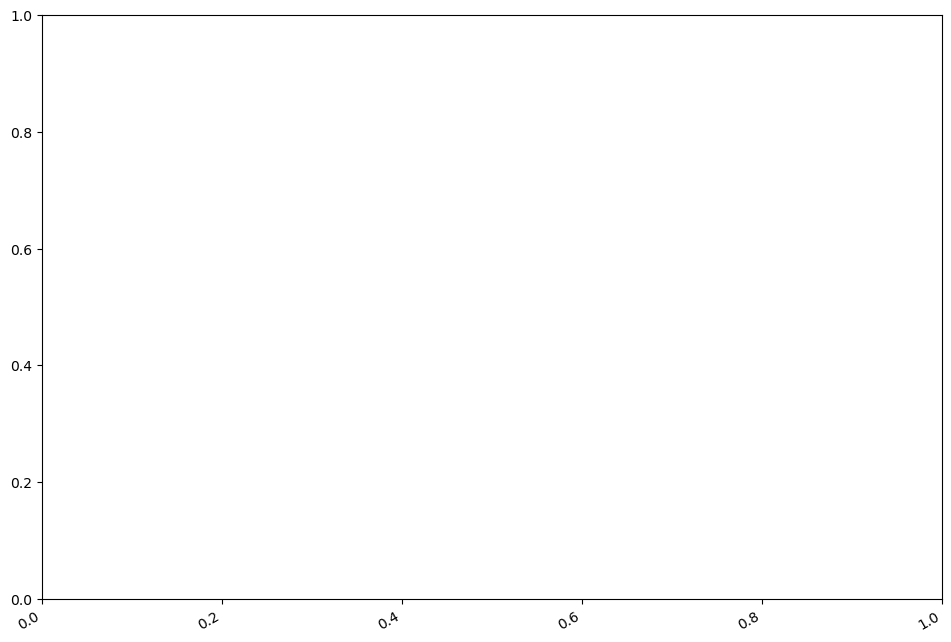

In [66]:
plot_movehisto2d_time(times, dts, y_param='lag',
                      x_label='Time',y_label='Delay Time (samples)',title='Delay Time vs Time')